In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil, sys
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

sys.path.append("../")
# import mpscr_models as mpscr
import mpscr_models_flexible as mpscr
import pwexp_flexible as pwexp
import gndr_utils as utils
import mps

I0000 00:00:1786424499.856059   29331 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786424501.218158   29331 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Thetaflow version: 0.0.35


In [2]:
def build_neural_network_structure(n_outputs):
    """
        Builds our rigid defined neural network structure where the number of output parameters is specified manually.
        That allows us to use this same function to call the different model architectures we propose here.
    """
    def neural_network(model, seed = None):
        initializer = initializers.GlorotNormal(seed = seed)
        
        model.convolution1 = keras.layers.Conv2D(filters = 4, kernel_size = [7,7], padding = "same", activation = tf.nn.leaky_relu,
                                                kernel_initializer = initializer, dtype = tf.float32)
        model.pooling1 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
        
        model.convolution2 = keras.layers.Conv2D(filters = 8, kernel_size = [5,5], padding = "same", activation = tf.nn.leaky_relu,
                                                kernel_initializer = initializer, dtype = tf.float32)
        model.pooling2 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
        
        model.convolution3 = keras.layers.Conv2D(filters = 16, kernel_size = [5,5], padding = "same", activation = tf.nn.leaky_relu,
                                                kernel_initializer = initializer, dtype = tf.float32)
        model.pooling3 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
        model.convolution4 = keras.layers.Conv2D(filters = 32, kernel_size = [3,3], padding = "same", activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.pooling4 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
    
        model.convolution5 = keras.layers.Conv2D(filters = 64, kernel_size = [3,3], padding = "same", activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.pooling5 = keras.layers.MaxPool2D(pool_size = [2,2], strides = 2)
        
        model.flatten = keras.layers.Reshape(target_shape=(-1,))
        model.dense1 = keras.layers.Dense(units = 128, activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.dense2 = keras.layers.Dense(units = 4, activation = tf.nn.leaky_relu, kernel_initializer = initializer, dtype = tf.float32)
        model.dense3 = keras.layers.Dense(units = n_outputs, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = False)
        
    def neural_network_call(model, x_input, training = False):
        x = model.convolution1(x_input)
        x = model.pooling1(x)
        x = model.convolution2(x)
        x = model.pooling2(x)
        x = model.convolution3(x)
        x = model.pooling3(x)
        x = model.convolution4(x)
        x = model.pooling4(x)
        x = model.convolution5(x)
        x = model.pooling5(x)
        x = model.flatten(x)
        x = model.dense1(x)
        x = model.dense2(x)
        x = model.dense3(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.convolution1(x_input)
        x = model.pooling1(x)
        x = model.convolution2(x)
        x = model.pooling2(x)
        x = model.convolution3(x)
        x = model.pooling3(x)
        x = model.convolution4(x)
        x = model.pooling4(x)
        x = model.convolution5(x)
        x = model.pooling5(x)
        x = model.flatten(x)
        x = model.dense1(x)
        x = model.dense2(x)
        return x

    return neural_network, neural_network_call, neural_network_call_nolast

In [3]:
df = pd.read_csv("OASIS Data/patients_full_data.csv")
print("Data dimensions: {}".format(df.shape))
df.head(3)

Data dimensions: (737, 278)


,Unnamed: 0,oasis_id,time_days,delta,age_at_entry,age_at_death,gender,apoe,days_to_visit,age_at_visit,...,vol_wm_rh_superiorfrontal,vol_wm_rh_superiorparietal,vol_wm_rh_superiortemporal,vol_wm_rh_supramarginal,vol_wm_rh_frontalpole,vol_wm_rh_temporalpole,vol_wm_rh_transversetemporal,vol_wm_rh_insula,vol_left_unsegmented_white_matter,vol_right_unsegmented_white_matter
0,0,OAS30001,5055,0,65.1945,NaN,2,23.0,5184,79.40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,OAS30002,2590,0,67.2521,76.9397,1,34.0,2961,75.36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,OAS30003,5093,0,58.8137,NaN,2,33.0,5651,74.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


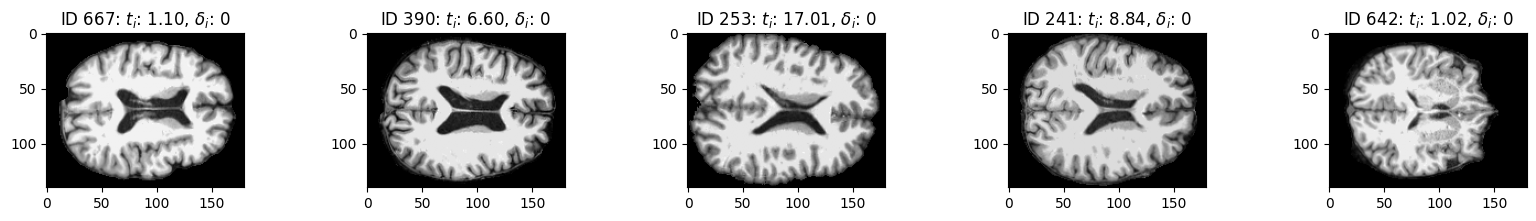

In [4]:
x = np.load("OASIS Data/patients_images.npy")
x = np.expand_dims(x, axis=-1)

np.random.seed(12)

random_idx = np.random.choice(np.arange(x.shape[0]), size = 5)

fig, ax = plt.subplots(nrows = 1, ncols = 5, figsize = (20,2))

for i, a in enumerate(ax):
    idx = random_idx[i]
    a.imshow(x[idx,:,:,0], cmap = "gray")
    a.set_title(r"ID {}: $t_i$: {:.2f}, $\delta_i$: {}".format(idx, df.loc[idx, "time_days"] / 365, df.loc[idx, "delta"]))

Events that happened after 12 years: 6
Train dimension: (552,)
Test dimension: (185,)


(0.0, 1.05)

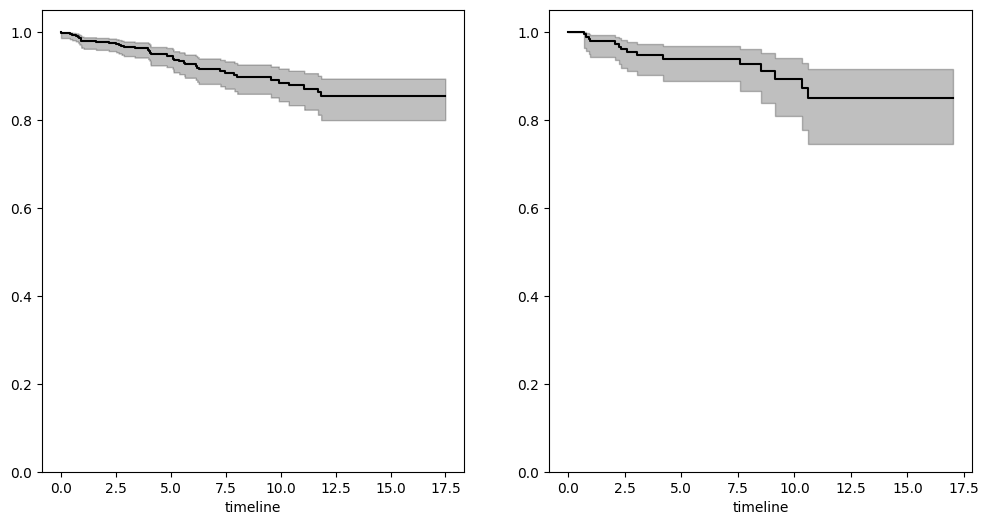

In [5]:
import oasis_utils

# Load OASIS data
# - Split into 75%/25% train/test sets
# - Stratify data according to the number of observed events
y_train, delta_train, x_train, y_test, delta_test, x_test =\
oasis_utils.load_oasis_data(long_term_limit = 15, train_size = 0.75, random_state = 20, stratify = True, verbose = True)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

km = lifelines.KaplanMeierFitter()
km.fit(y_train, delta_train)
km.plot(ax = ax[0], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

km = lifelines.KaplanMeierFitter()
km.fit(y_test, delta_test)
km.plot(ax = ax[1], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

ax[0].set_ylim(0, 1.05)
ax[1].set_ylim(0, 1.05)
plt.show()

In [6]:
def load_exponential_model(dist, model_type, filename,
                       y_train, delta_train, x_train, y_test, delta_test, x_test,
                       fixed_q = 0.0, ngrid = 100):
    exp_spec = mpscr.BaseExponential()
    # Include the directory for the Exponential model results
    filename = "OASIS Results/ExponentialBase/{}".format(filename)

    dist = dist.lower()
    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "geometric"):
        model_spec = mpscr.MPSNegBinomial(1.0)
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    elif(dist == "rgp"):
        model_spec = mpscr.MPSRGP()
    else:
        raise Exception("Please, provide a valid subfamily name.")

    if(model_type == "simple"):
        with tf.device("/CPU:0"):
            model = mpscr.build_simple_mpscr_model(y_train, delta_train, model_spec, exp_spec, seed = 10 )
            model.load_model(filename)
            model_results = model.get_survival_cure(y_train, delta_train, y_test, delta_test, ngrid = ngrid)
    elif(model_type == "medium"):
        with tf.device("/GPU:0"):
            medium_neural_network, medium_neural_network_call, medium_neural_network_call_nolast = build_neural_network_structure(1)
            model = mpscr.build_medium_mpscr_model(y_train, delta_train, x_train.shape[1:], model_spec, exp_spec,
                                                   neural_network = medium_neural_network, neural_network_call = medium_neural_network_call,
                                                   neural_network_call_nolast = medium_neural_network_call_nolast,
                                                   seed = 10)
            model.load_model(filename)
            model_results = model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = ngrid)
    
    
    return model, model_results

In [7]:
poisson_simple_model, poisson_simple_results = load_exponential_model("poisson", "simple", "poisson_simple",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_simple_model, bin5_simple_results = load_exponential_model("bin", "simple", "bin5_simple",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                                fixed_q = 5)
negbin_simple_model, negbin_simple_results = load_exponential_model("negbin", "simple", "negbin_simple",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test)
log_simple_model, log_simple_results = load_exponential_model("log", "simple", "log_simple",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_simple_model, rgp_simple_results = load_exponential_model("rgp", "simple", "rgp_simple",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)

Model successfully loaded from OASIS Results/ExponentialBase/poisson_simple.
Model successfully loaded from OASIS Results/ExponentialBase/bin5_simple.
Model successfully loaded from OASIS Results/ExponentialBase/negbin_simple.
Model successfully loaded from OASIS Results/ExponentialBase/log_simple.
Model successfully loaded from OASIS Results/ExponentialBase/rgp_simple.


In [8]:
poisson_medium_model, poisson_medium_results = load_exponential_model("poisson", "medium", "poisson_medium",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_medium_model, bin5_medium_results = load_exponential_model("bin", "medium", "bin5_medium",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                                fixed_q = 5)
negbin_medium_model, negbin_medium_results = load_exponential_model("negbin", "medium", "negbin_medium",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test)
log_medium_model, log_medium_results = load_exponential_model("log", "medium", "log_medium",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_medium_model, rgp_medium_results = load_exponential_model("rgp", "medium", "rgp_medium",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)

Model successfully loaded from OASIS Results/ExponentialBase/poisson_medium.
Model successfully loaded from OASIS Results/ExponentialBase/bin5_medium.
Model successfully loaded from OASIS Results/ExponentialBase/negbin_medium.
Model successfully loaded from OASIS Results/ExponentialBase/log_medium.
Model successfully loaded from OASIS Results/ExponentialBase/rgp_medium.


In [9]:
resid_poisson_simple_train = utils.compute_randomized_residuals_censoring( poisson_simple_results["S_train"], poisson_simple_results["delta_train"] )
resid_bin5_simple_train = utils.compute_randomized_residuals_censoring( bin5_simple_results["S_train"], bin5_simple_results["delta_train"] )
resid_negbin_simple_train = utils.compute_randomized_residuals_censoring( negbin_simple_results["S_train"], negbin_simple_results["delta_train"] )
resid_log_simple_train = utils.compute_randomized_residuals_censoring( log_simple_results["S_train"], log_simple_results["delta_train"] )
resid_rgp_simple_train = utils.compute_randomized_residuals_censoring( rgp_simple_results["S_train"], rgp_simple_results["delta_train"] )

resid_poisson_simple_test = utils.compute_randomized_residuals_censoring( poisson_simple_results["S_test"], poisson_simple_results["delta_test"] )
resid_bin5_simple_test = utils.compute_randomized_residuals_censoring( bin5_simple_results["S_test"], bin5_simple_results["delta_test"] )
resid_negbin_simple_test = utils.compute_randomized_residuals_censoring( negbin_simple_results["S_test"], negbin_simple_results["delta_test"] )
resid_log_simple_test = utils.compute_randomized_residuals_censoring( log_simple_results["S_test"], log_simple_results["delta_test"] )
resid_rgp_simple_test = utils.compute_randomized_residuals_censoring( rgp_simple_results["S_test"], rgp_simple_results["delta_test"] )

In [10]:
resid_poisson_medium_train = utils.compute_randomized_residuals_censoring( poisson_medium_results["S_train"], poisson_medium_results["delta_train"] )
resid_bin5_medium_train = utils.compute_randomized_residuals_censoring( bin5_medium_results["S_train"], bin5_medium_results["delta_train"] )
resid_negbin_medium_train = utils.compute_randomized_residuals_censoring( negbin_medium_results["S_train"], negbin_medium_results["delta_train"] )
resid_log_medium_train = utils.compute_randomized_residuals_censoring( log_medium_results["S_train"], log_medium_results["delta_train"] )
resid_rgp_medium_train = utils.compute_randomized_residuals_censoring( rgp_medium_results["S_train"], rgp_medium_results["delta_train"] )

resid_poisson_medium_test = utils.compute_randomized_residuals_censoring( poisson_medium_results["S_test"], poisson_medium_results["delta_test"] )
resid_bin5_medium_test = utils.compute_randomized_residuals_censoring( bin5_medium_results["S_test"], bin5_medium_results["delta_test"] )
resid_negbin_medium_test = utils.compute_randomized_residuals_censoring( negbin_medium_results["S_test"], negbin_medium_results["delta_test"] )
resid_log_medium_test = utils.compute_randomized_residuals_censoring( log_medium_results["S_test"], log_medium_results["delta_test"] )
resid_rgp_medium_test = utils.compute_randomized_residuals_censoring( rgp_medium_results["S_test"], rgp_medium_results["delta_test"] )

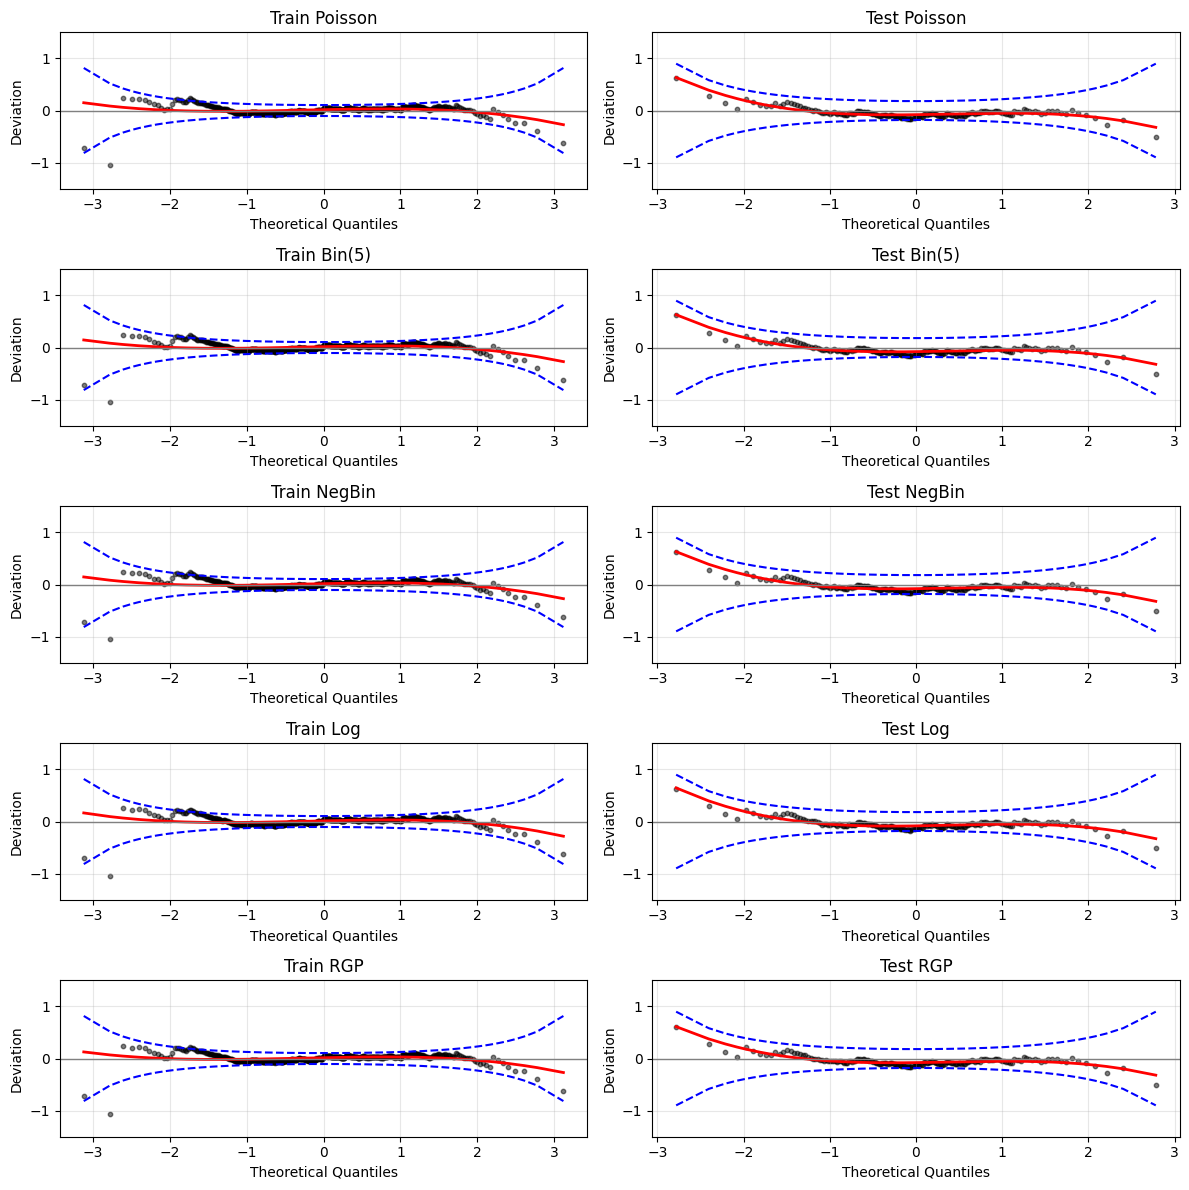

In [11]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, figsize = (12,12))

utils.plot_worm(resid_poisson_simple_train, ax = ax[0,0], title = "Train Poisson")
utils.plot_worm(resid_bin5_simple_train, ax = ax[1,0], title = "Train Bin(5)")
utils.plot_worm(resid_negbin_simple_train, ax = ax[2,0], title = "Train NegBin")
utils.plot_worm(resid_log_simple_train, ax = ax[3,0], title = "Train Log")
utils.plot_worm(resid_rgp_simple_train, ax = ax[4,0], title = "Train RGP")

utils.plot_worm(resid_poisson_simple_test, ax = ax[0,1], title = "Test Poisson")
utils.plot_worm(resid_bin5_simple_test, ax = ax[1,1], title = "Test Bin(5)")
utils.plot_worm(resid_negbin_simple_test, ax = ax[2,1], title = "Test NegBin")
utils.plot_worm(resid_log_simple_test, ax = ax[3,1], title = "Test Log")
utils.plot_worm(resid_rgp_simple_test, ax = ax[4,1], title = "Test RGP")

fig.tight_layout()
plt.show()

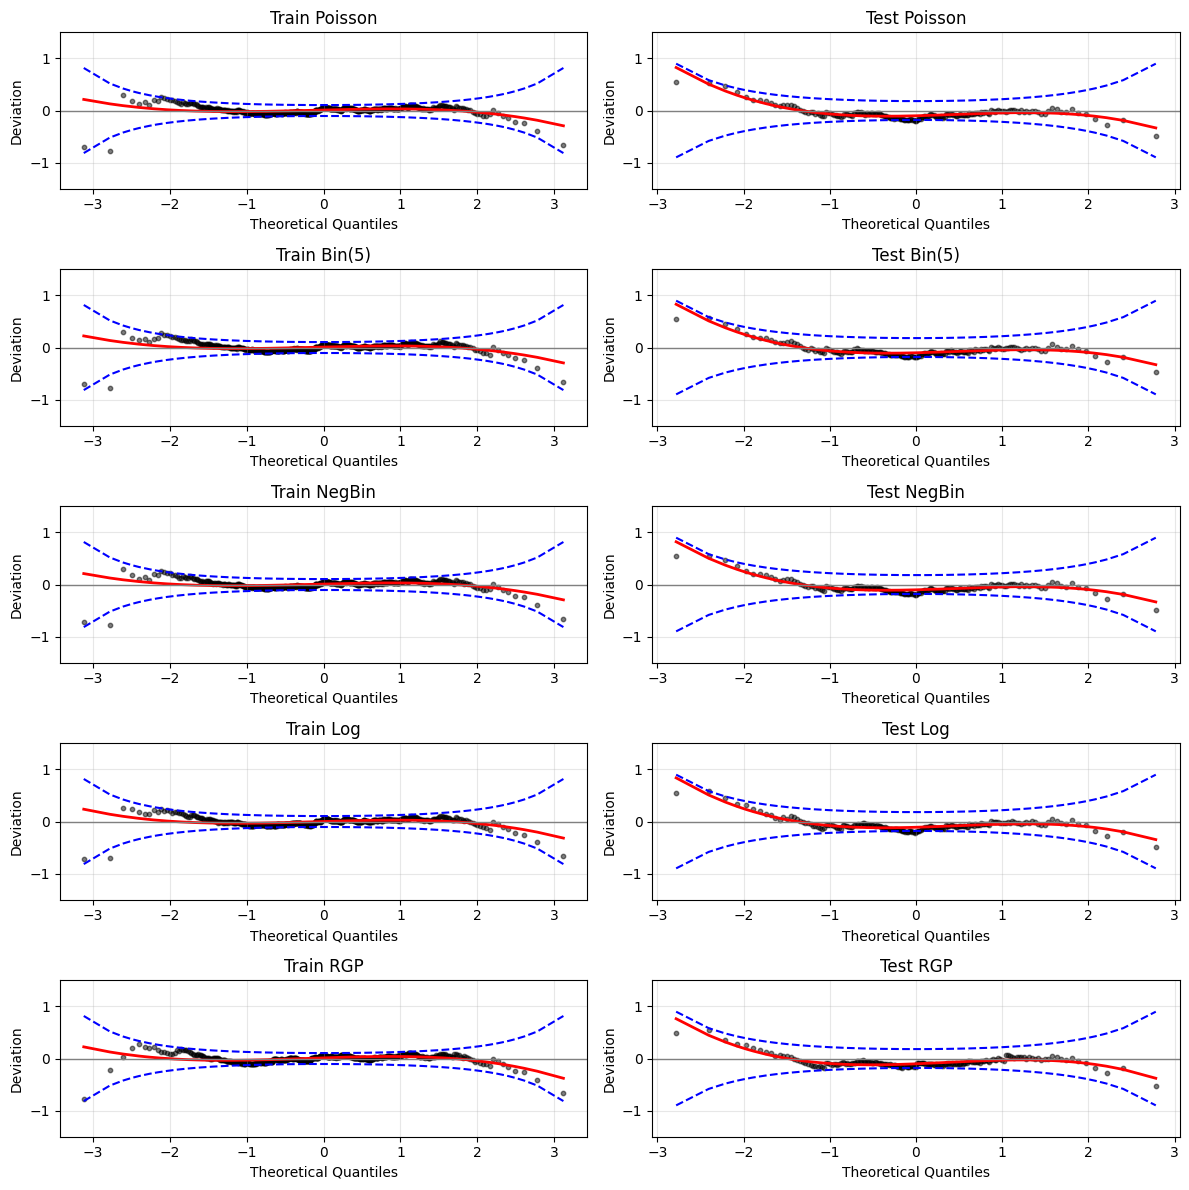

In [12]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, figsize = (12,12))

utils.plot_worm(resid_poisson_medium_train, ax = ax[0,0], title = "Train Poisson")
utils.plot_worm(resid_bin5_medium_train, ax = ax[1,0], title = "Train Bin(5)")
utils.plot_worm(resid_negbin_medium_train, ax = ax[2,0], title = "Train NegBin")
utils.plot_worm(resid_log_medium_train, ax = ax[3,0], title = "Train Log")
utils.plot_worm(resid_rgp_medium_train, ax = ax[4,0], title = "Train RGP")

utils.plot_worm(resid_poisson_medium_test, ax = ax[0,1], title = "Test Poisson")
utils.plot_worm(resid_bin5_medium_test, ax = ax[1,1], title = "Test Bin(5)")
utils.plot_worm(resid_negbin_medium_test, ax = ax[2,1], title = "Test NegBin")
utils.plot_worm(resid_log_medium_test, ax = ax[3,1], title = "Test Log")
utils.plot_worm(resid_rgp_medium_test, ax = ax[4,1], title = "Test RGP")

fig.tight_layout()
plt.show()

In [13]:
from scipy.stats import anderson

In [14]:
simple_models_resid_train = [resid_poisson_simple_train, resid_bin5_simple_train, resid_negbin_simple_train, resid_log_simple_train, resid_rgp_simple_train]
simple_models_resid_test = [resid_poisson_simple_test, resid_bin5_simple_test, resid_negbin_simple_test, resid_log_simple_test, resid_rgp_simple_test]
medium_models_resid_train = [resid_poisson_medium_train, resid_bin5_medium_train, resid_negbin_medium_train, resid_log_medium_train, resid_rgp_medium_train]
medium_models_resid_test = [resid_poisson_medium_test, resid_bin5_medium_test, resid_negbin_medium_test, resid_log_medium_test, resid_rgp_medium_test]

simple_models_train_ad = []
simple_models_test_ad = []
medium_models_train_ad = []
medium_models_test_ad = []
for i in range(len(simple_models_resid_train)):
    simple_models_train_ad.append( anderson(simple_models_resid_train[i]).statistic )
    simple_models_test_ad.append( anderson(simple_models_resid_test[i]).statistic )
    medium_models_train_ad.append( anderson(medium_models_resid_train[i]).statistic )
    medium_models_test_ad.append( anderson(medium_models_resid_test[i]).statistic )

df_results = pd.DataFrame({
    "Model": ["Poisson", "Bin(5)", "NegBin", "Log", "RGP"],
    "Simple Train": simple_models_train_ad,
    "Simple Test": simple_models_test_ad,
    "Medium Train": medium_models_train_ad,
    "Medium Test": medium_models_test_ad
})
df_results

,Model,Simple Train,Simple Test,Medium Train,Medium Test
0,Poisson,0.629496,0.397281,0.615880,0.622122
1,Bin(5),0.624140,0.394880,0.650804,0.620302
2,NegBin,0.625411,0.395266,0.604567,0.618609
3,Log,0.649130,0.405188,0.619057,0.646587
4,RGP,0.598295,0.382682,0.592011,0.512559


# Predictive metrics

In [109]:
import evaluation_metrics as eval_metrics

In [111]:
eval_metrics.calculate_integrated_ipcw_brier_score

<function evaluation_metrics.calculate_integrated_ipcw_brier_score(results_dict)>

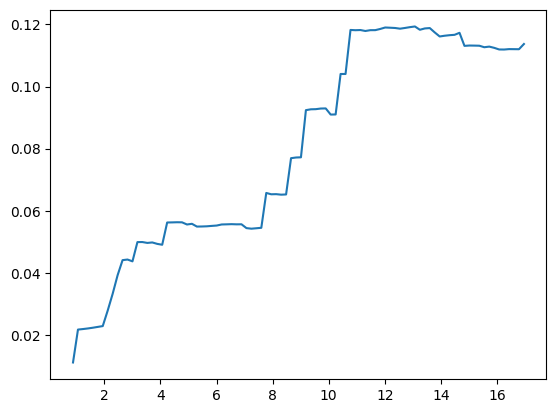

In [113]:
results_dict = poisson_medium_results
# results_dict = poisson_simple_results
times, bs_times = eval_metrics.calculate_ipcw_brier_score(results_dict)

# ibs = integrated_brier_score(train_surv, test_surv, eval_surv_probs, eval_times)

plt.plot(times, bs_times)
plt.show()

In [86]:
results_dict = poisson_medium_results
# results_dict = poisson_simple_results

y_train = results_dict['y_train'].flatten()
delta_train = results_dict['delta_train'].flatten().astype(bool)
y_test = results_dict['y_test'].flatten()
delta_test = results_dict['delta_test'].flatten().astype(bool)

ts_grid = results_dict['ts_grid'].flatten()
S_ts_test = results_dict["S_ts_test"]

# Create structured arrays required by scikit-survival
dt = np.dtype([('event', 'bool'), ('time', 'float')])
train_surv = np.empty( len(y_train), dtype = dt )
train_surv['event'], train_surv['time'] = delta_train, y_train
test_surv = np.empty(len(y_test), dtype=dt)
test_surv['event'], test_surv['time'] = delta_test, y_test

# The bounds must be strictly within the TEST set's follow-up limits
min_time = np.min( y_test[delta_test] ) + 1e-5
max_time = np.max( y_test ) - 1e-5

# Get the grid of values only on the regions where the times are adequate
safe_mask = (ts_grid > min_time) & (ts_grid < max_time)
eval_times = ts_grid[safe_mask]
eval_surv_probs = S_ts_test[:, safe_mask]
if(eval_surv_probs.shape[0] == 1):
    eval_surv_probs = np.repeat(eval_surv_probs, y_test.shape[0], axis = 0)

# Calculate Time-Dependent Brier Score
times, brier_scores = brier_score(train_surv, test_surv, eval_surv_probs, eval_times)

brier_scores.shape

(92,)

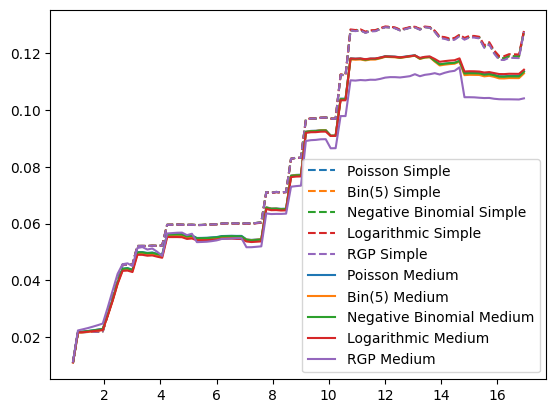

In [16]:
times, brier_scores_poisson_simple = calculate_ipcw_brier_score( poisson_simple_results )
_, brier_scores_bin5_simple = calculate_ipcw_brier_score( bin5_simple_results )
_, brier_scores_negbin_simple = calculate_ipcw_brier_score( negbin_simple_results )
_, brier_scores_log_simple = calculate_ipcw_brier_score( log_simple_results )
_, brier_scores_rgp_simple = calculate_ipcw_brier_score( rgp_simple_results )

_, brier_scores_poisson_medium = calculate_ipcw_brier_score( poisson_medium_results )
_, brier_scores_bin5_medium = calculate_ipcw_brier_score( bin5_medium_results )
_, brier_scores_negbin_medium = calculate_ipcw_brier_score( negbin_medium_results )
_, brier_scores_log_medium = calculate_ipcw_brier_score( log_medium_results )
_, brier_scores_rgp_medium = calculate_ipcw_brier_score( rgp_medium_results )

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.plot(times, brier_scores_poisson_simple, linestyle = "dashed", label = "Poisson Simple", color = colors[0])
plt.plot(times, brier_scores_bin5_simple, linestyle = "dashed", label = "Bin(5) Simple", color = colors[1])
plt.plot(times, brier_scores_negbin_simple, linestyle = "dashed", label = "Negative Binomial Simple", color = colors[2])
plt.plot(times, brier_scores_log_simple, linestyle = "dashed", label = "Logarithmic Simple", color = colors[3])
plt.plot(times, brier_scores_rgp_simple, linestyle = "dashed", label = "RGP Simple", color = colors[4])

plt.plot(times, brier_scores_poisson_medium, label = "Poisson Medium", color = colors[0])
plt.plot(times, brier_scores_bin5_medium, label = "Bin(5) Medium", color = colors[1])
plt.plot(times, brier_scores_negbin_medium, label = "Negative Binomial Medium", color = colors[2])
plt.plot(times, brier_scores_log_medium, label = "Logarithmic Medium", color = colors[3])
plt.plot(times, brier_scores_rgp_medium, label = "RGP Medium", color = colors[4])
plt.legend()

plt.show()

In [26]:
def calculate_unos_auc(results_dict):
    """
    Calculates Uno's Cumulative/Dynamic Time-Dependent AUC.
    Higher AUC is better (1.0 is perfect discrimination).
    """
    y_train = np.ravel(results_dict['y_train'])
    delta_train = np.ravel(results_dict['delta_train']).astype(bool)
    y_test = np.ravel(results_dict['y_test'])
    delta_test = np.ravel(results_dict['delta_test']).astype(bool)
    
    ts_grid = np.ravel(results_dict['ts_grid'])
    
    # Check orientation of S_ts_test
    S_ts_test = results_dict['S_ts_test']
    if S_ts_test.shape[1] != len(ts_grid):
        S_ts_test = S_ts_test.T
    
    # Create structured arrays
    dt = np.dtype([('event', 'bool'), ('time', 'float')])
    train_surv = np.empty(len(y_train), dtype=dt)
    train_surv['event'], train_surv['time'] = delta_train, y_train
    
    test_surv = np.empty(len(y_test), dtype=dt)
    test_surv['event'], test_surv['time'] = delta_test, y_test
    
    # --- THE FIX ---
    min_time = y_test[delta_test].min() + 1e-5
    max_time = y_test.max() - 1e-5
    
    safe_mask = (ts_grid > min_time) & (ts_grid < max_time)
    eval_times = ts_grid[safe_mask]
    
    # AUC requires "Risk Scores". 
    # Survival probability is the inverse of risk, so we use 1.0 - S(t)
    risk_scores = 1.0 - S_ts_test[:, safe_mask]
    if(risk_scores.shape[0] == 1):
        risk_scores = np.repeat(risk_scores, y_test.shape[0], axis = 0)
    
    # Calculate Uno's AUC
    auc, mean_auc = cumulative_dynamic_auc(train_surv, test_surv, risk_scores, eval_times)
    
    return eval_times, auc, mean_auc

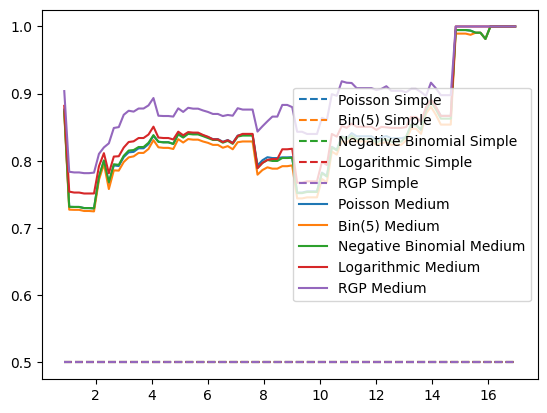

In [27]:
times, uno_auc_poisson_simple, mean_uno_auc_poisson_simple = calculate_unos_auc( poisson_simple_results )
_, uno_auc_bin5_simple, mean_uno_auc_bin5_simple = calculate_unos_auc( bin5_simple_results )
_, uno_auc_negbin_simple, mean_uno_auc_negbin_simple = calculate_unos_auc( negbin_simple_results )
_, uno_auc_log_simple, mean_uno_auc_log_simple = calculate_unos_auc( log_simple_results )
_, uno_auc_rgp_simple, mean_uno_auc_rgp_simple = calculate_unos_auc( rgp_simple_results )

_, uno_auc_poisson_medium, mean_uno_auc_poisson_medium = calculate_unos_auc( poisson_medium_results )
_, uno_auc_bin5_medium, mean_uno_auc_bin5_medium = calculate_unos_auc( bin5_medium_results )
_, uno_auc_negbin_medium, mean_uno_auc_negbin_medium = calculate_unos_auc( negbin_medium_results )
_, uno_auc_log_medium, mean_uno_auc_log_medium = calculate_unos_auc( log_medium_results )
_, uno_auc_rgp_medium, mean_uno_auc_rgp_medium = calculate_unos_auc( rgp_medium_results )

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.plot(times, uno_auc_poisson_simple, linestyle = "dashed", label = "Poisson Simple", color = colors[0])
plt.plot(times, uno_auc_bin5_simple, linestyle = "dashed", label = "Bin(5) Simple", color = colors[1])
plt.plot(times, uno_auc_negbin_simple, linestyle = "dashed", label = "Negative Binomial Simple", color = colors[2])
plt.plot(times, uno_auc_log_simple, linestyle = "dashed", label = "Logarithmic Simple", color = colors[3])
plt.plot(times, uno_auc_rgp_simple, linestyle = "dashed", label = "RGP Simple", color = colors[4])

plt.plot(times, uno_auc_poisson_medium, label = "Poisson Medium", color = colors[0])
plt.plot(times, uno_auc_bin5_medium, label = "Bin(5) Medium", color = colors[1])
plt.plot(times, uno_auc_negbin_medium, label = "Negative Binomial Medium", color = colors[2])
plt.plot(times, uno_auc_log_medium, label = "Logarithmic Medium", color = colors[3])
plt.plot(times, uno_auc_rgp_medium, label = "RGP Medium", color = colors[4])
plt.legend()

plt.show()